# Guided Label Propagation — Tool Demo

*Semi-supervised community detection for large-scale information-sharing networks.*

The `guidedLP` package propagates a small set of labelled "seed" nodes through a network to score every other node's affinity for those labels. Unlike unsupervised community detection (Louvain, Leiden, …) which produces arbitrary clusters that must be interpreted post-hoc, GLP starts from labels of substantive interest and tells you how the rest of the graph relates to them.

This notebook walks through the tool's main capabilities on a Danish public-Facebook URL-sharing corpus, covering:

1. **Speed & memory on large data.** Polars + NetworkIt + a streamlined backboning pipeline (`run_canonical_pipeline`) — millions of edges in seconds.
2. **Noise regularization as an interpretable knob.** The `noise` category sinks "I don't know" mass, and `train_test_split_validation` separates *noise errors* (recoverable) from *hard errors* (real model mistakes).
3. **Reduced-graph export with full attributes.** `export_reduced_graph` produces a Gephi-ready file with every label probability and the noise score attached to each node.
4. **Cross-domain seeding.** Stat-user augmentation (`make_stat_user_edges`) lets you propagate labels that live on a *different* partition from the nodes you want to classify — e.g. seed with partisan newspaper URLs, classify Facebook pages.


## Structure

| Section | What it shows |
|---|---|
| 2. Math & architecture | The propagation update + the canonical pipeline shape |
| 3. The algorithm at work | Iteration snapshots on toy graphs (clean + messy + noise category) |
| 4. Pipeline + train/test on Facebook data | The headline pipeline call; noise vs hard errors |
| 5. Cross-domain: partisan news → politicians | Stat-user augmentation; custom test seeds |
| 6. Visualization + Gephi export | Three-panel matplotlib + GEXF |
| 7. Recap | Tying each claim back to a section |

> **Data placeholders.** The notebook expects three files under `data/`: `dk_fb_shares.parquet`, `partisan_newspapers.csv`, `politicians_labels.csv`. See the config cell in Section 4 for the expected schemas.

> **Two seed sets.** *Politicians* (Facebook page nodes, with party affiliation) and *partisan news* (URL / domain nodes, with partisan label). Section 4 trains on politicians and tests on a held-out slice of politicians (in-domain). Section 5 trains on partisan news URLs via stat-user augmentation and tests on politicians (cross-domain).

## 2. Math & architecture

### Propagation update

Given a graph with adjacency $A$ and seed-label matrix $Y$ (one column per label, $Y_{ij}=1$ if node $i$ is a seed with label $j$), GLP iterates

$$F^{(t+1)} = \alpha \, P \, F^{(t)} + (1-\alpha)\, Y$$

where $P = D^{-1}A$ is the row-normalized transition matrix. With $\alpha = 0.85$ (default), each step is a weighted average of (a) the labels seen at each node's neighbors and (b) the original seed mass — the $(1-\alpha)Y$ term keeps seeds anchored throughout, so they can't drift. Iteration stops when $\max|F^{(t+1)} - F^{(t)}| < 10^{-6}$, typically within 20–30 steps.

For directed graphs `directional=True` runs propagation twice — once on $A$ (out-neighbors) and once on $A^\top$ (in-neighbors) — and returns both. Under the canonical pipeline's edge convention (later sharer → earlier sharer), the **out-pass** labels each page by the affinity of *the pages it shares from*; the in-pass labels each page by *who reshares it*.

### Noise category as regularization

When `enable_noise_category=True`, a `noise` label is added and assigned to a random `noise_ratio × n_seeds` non-seed nodes. Nodes far from any *real* seed inherit noise mass instead of the closest substantive label — a built-in "don't know" sink. This is the regularization knob: high `noise_ratio` pulls peripheral nodes toward "unknown"; low values let the real labels propagate further. Section 4 sweeps `noise_ratio` ∈ {0, 0.1, 0.3, 0.5, 1.0}.

### Canonical pipeline

`run_canonical_pipeline` composes the four standard stages of attribution-style analyses:

```
raw CSV / Parquet
  └─ build_edgelist_from_frame         ──►  bipartite EdgeList (UInt32 codes)
       └─ apply_backbone(bipartite_svn)  ──►  statistically significant ties
            └─ temporal_bipartite_to_unipartite  ──►  directed page→page graph
                                                     (later sharer → earlier sharer)
                 └─ apply_backbone(noise_corrected)  ──►  backboned projection
```

with three memory modes (`fast`/`balanced`/`low`) that produce byte-identical output but trade peak RAM for wall-clock. We use `fast` below.


In [2]:
"""All imports for the rest of the notebook."""
from pathlib import Path
import warnings

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkit as nk

# Public guidedLP API
from guidedLP.common.id_mapper import IDMapper
from guidedLP.common.seed_input import normalize_seed_input
from guidedLP.network.construction import (
    build_graph_from_edgelist,
    edgelist_to_graph,
)
from guidedLP.network.communities import detect_communities
from guidedLP.network.reduction import export_reduced_graph
from guidedLP.network.filtering import filter_by_seed_proximity
from guidedLP.glp import winsorize_transform
from guidedLP.glp import (
    guided_label_propagation,
    ensemble_label_propagation,
    train_test_split_validation,
    get_validation_summary,
    make_stat_user_edges,
    get_seed_statistics,
    check_seed_coverage,
    GLPGridSearch,
)

import logging
logging.getLogger("guidedLP").setLevel(logging.ERROR)
# Internal helpers — used in Section 3 only, to capture per-iteration F.
# Not stable API; OK for a sketch.
from guidedLP.glp.propagation import (
    _initialize_label_matrix,
    _create_transition_matrix,
    _generate_noise_seeds,
)
from guidedLP.pipelines import run_canonical_pipeline

# Optional: NetworkX (for spring layout).
try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False

# Jupyter display helper; degrades gracefully outside a kernel.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

warnings.filterwarnings("ignore", category=UserWarning, module="networkit")
#print(f"networkx: {'yes' if HAS_NX else 'no'}")


## 3. The algorithm at work

Two examples on toy graphs before we scale to the Facebook data:

- **3a — Clean two-community graph.** Shows the basic propagation mechanic. We capture $F^{(t)}$ at every iteration and render snapshots at $t = 0, 1, 2, 8,$ converged.
- **3b — Messier three-community graph with peripheral nodes.** Shows the role of the noise category: when GLP is run *without* noise, every node is forced into one of the real labels including the unlabelled fringe community and the low-degree stragglers — pure overfitting. With `enable_noise_category=True`, structurally-distant regions go to the `noise` class instead.

### 3a. Clean two-community graph

A 90-node graph with two well-defined communities (45 nodes each) and a handful of bridge edges. We seed 3 nodes per community. Mass starts concentrated on the 6 seeds (`t=0`), spreads to immediate neighbors (`t=1, 2`), saturates each community (`t=8`), and stabilizes once neighbor pulls balance the $(1-\alpha)Y$ anchor (converged).


In [3]:
# Define toy graph
def build_toy_graph(rng_seed: int = 0, community_size: int = 45):
    """Two communities, sparse intra-community edges, a handful of bridges."""
    rng = np.random.default_rng(rng_seed)
    n = 2 * community_size
    g = nk.Graph(n, weighted=True, directed=False)

    p_intra = 0.15
    for i in range(community_size):
        for j in range(i + 1, community_size):
            if rng.random() < p_intra:
                g.addEdge(i, j, w=1.0)
            if rng.random() < p_intra:
                g.addEdge(i + community_size, j + community_size, w=1.0)

    # Half a dozen bridge edges between the two communities.
    n_bridges = 6
    a_picks = rng.choice(community_size, size=n_bridges, replace=False)
    b_picks = rng.choice(community_size, size=n_bridges, replace=False) + community_size
    for u, v in zip(a_picks, b_picks):
        g.addEdge(int(u), int(v), w=1.0)

    mapper = IDMapper.from_originals([f"n{i:02d}" for i in range(n)])
    return g, mapper, community_size

toy_graph, toy_mapper, COMM_SZ = build_toy_graph()
toy_seeds = {
    "n00": "left",  "n01": "left",  "n02": "left",
    f"n{COMM_SZ:02d}": "right", f"n{COMM_SZ+1:02d}": "right", f"n{COMM_SZ+2:02d}": "right",
}
toy_labels = ["left", "right"]
print(f"Toy graph: {toy_graph.numberOfNodes()} nodes "
      f"({COMM_SZ} per community), "
      f"{toy_graph.numberOfEdges()} edges, "
      f"{len(toy_seeds)} seeds (3 per community)")


Toy graph: 90 nodes (45 per community), 311 edges, 6 seeds (3 per community)


In [4]:
# Simulate propagation
def propagate_with_snapshots(graph, mapper, seeds, labels,
                             alpha: float = 0.85,
                             max_iterations: int = 60,
                             tol: float = 1e-6):
    """Run the GLP fixed-point and return [F_0, F_1, ..., F_T].

    F_0 is the seed matrix Y. F_t for t>=1 is the post-iteration state.
    Same update as guided_label_propagation but keeps every snapshot.
    """
    Y = _initialize_label_matrix(graph, mapper, seeds, labels)
    P = _create_transition_matrix(graph, direction="out_degree")
    F = Y.copy()
    snapshots = [F.copy()]
    for _ in range(max_iterations):
        F_next = alpha * (P @ F) + (1.0 - alpha) * Y
        delta = float(np.abs(F_next - F).max())
        F = F_next
        snapshots.append(F.copy())
        if delta < tol:
            break
    return snapshots

snapshots = propagate_with_snapshots(toy_graph, toy_mapper, toy_seeds, toy_labels)
print(f"Converged after {len(snapshots) - 1} iterations "
      f"(captured {len(snapshots)} snapshots including t=0).")


Converged after 38 iterations (captured 39 snapshots including t=0).


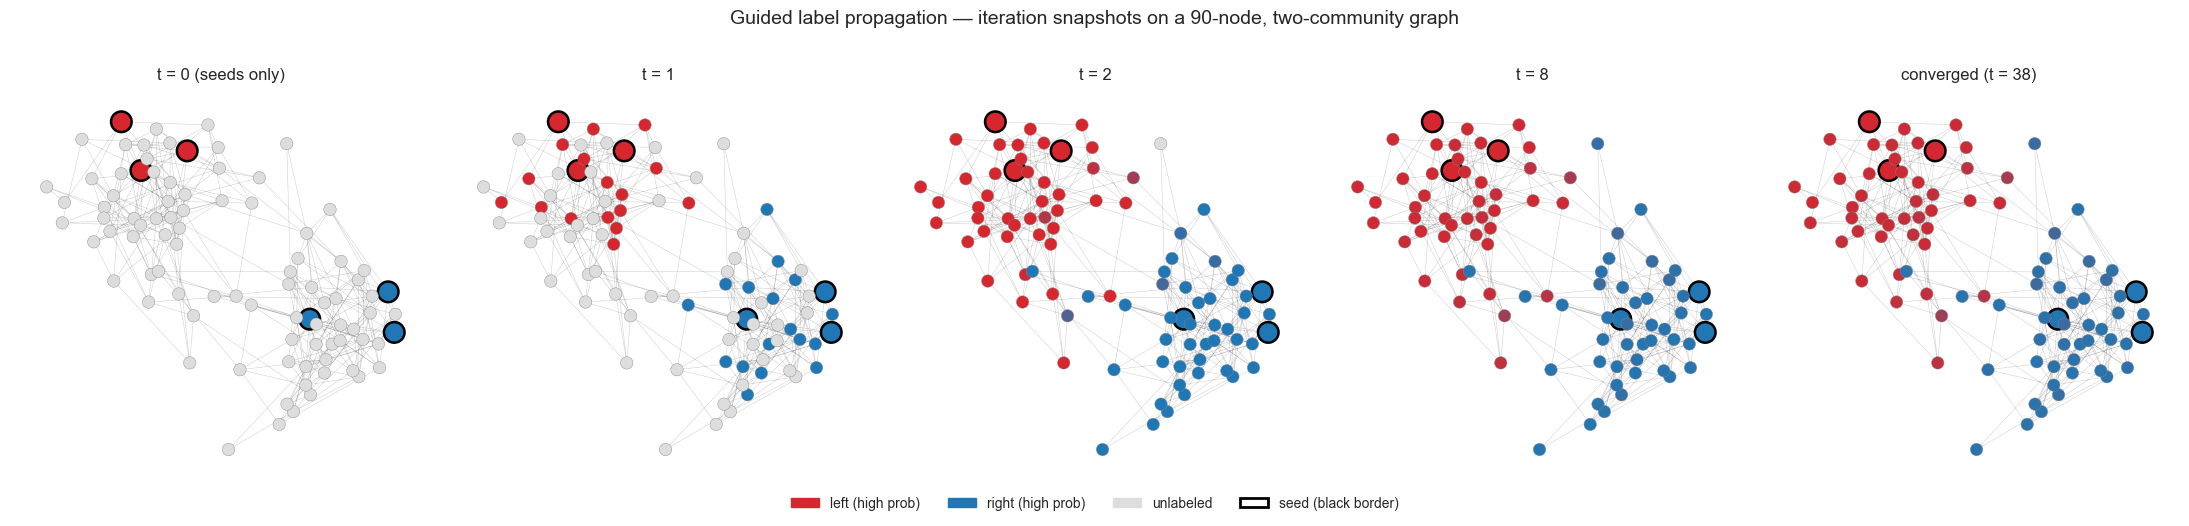

In [5]:
#Build Toy Graph Example
G = nx.Graph()
for i in range(toy_graph.numberOfNodes()):
    G.add_node(toy_mapper.get_original(i))
for u, v in toy_graph.iterEdges():
    G.add_edge(toy_mapper.get_original(u), toy_mapper.get_original(v))
pos = nx.spring_layout(G, seed=42, k=0.5)

converged_idx = len(snapshots) - 1
panel_indices = [0, 1, 2, 8, converged_idx]
panel_titles = ["t = 0 (seeds only)", "t = 1", "t = 2", "t = 8",
                f"converged (t = {converged_idx})"]

seed_set = set(toy_seeds.keys())
color_left  = np.array([0.84, 0.15, 0.18])  # red
color_right = np.array([0.12, 0.47, 0.71])  # blue

fig, axes = plt.subplots(1, 5, figsize=(22, 4.8))
for ax, t_idx, title in zip(axes, panel_indices, panel_titles):
    F = snapshots[t_idx]
    row_sums = F.sum(axis=1, keepdims=True)
    F_norm = np.where(row_sums > 0, F / np.maximum(row_sums, 1e-12), 0.0)

    node_ids = [toy_mapper.get_original(i) for i in range(toy_graph.numberOfNodes())]
    colors, sizes, edgecolors, linewidths = [], [], [], []
    for i, nid in enumerate(node_ids):
        if F_norm[i].sum() == 0:
            colors.append("#dddddd")
        else:
            blended = F_norm[i, 0] * color_left + F_norm[i, 1] * color_right
            colors.append(tuple(np.clip(blended, 0, 1)))
        sizes.append(220 if nid in seed_set else 80)
        edgecolors.append("black" if nid in seed_set else "#888")
        linewidths.append(1.8 if nid in seed_set else 0.3)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.18, width=0.4)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend_elements = [
    mpatches.Patch(color=tuple(color_left),  label="left (high prob)"),
    mpatches.Patch(color=tuple(color_right), label="right (high prob)"),
    mpatches.Patch(color="#dddddd",          label="unlabeled"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2,
                   label="seed (black border)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.05), frameon=False)
fig.suptitle(f"Guided label propagation — iteration snapshots on a "
             f"{toy_graph.numberOfNodes()}-node, two-community graph",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3b. A messier graph — and the role of the noise category

Real information-sharing networks are messier than the clean two-community graph above:

- **Heterogeneous community sizes** — not every cluster is the same scale.
- **Cross-community edges** — people share across the aisle.
- **Peripheral / weakly-connected nodes** — accounts that share occasionally with no consistent affinity.
- **Whole communities with no labelled seeds** — entire content niches outside the substantive labels.

Here we build a **90-node graph with three communities** (left, right, and an unlabelled "fringe" community), plus 15 low-degree **straggler** nodes connected to one to three random anchors. Only the left and right communities are seeded.

Two GLP runs side by side:

- **Without noise** — `enable_noise_category=False` forces every node into `left` or `right`. The fringe community and the stragglers are painted whichever real label happens to win their local random walk — a confident misclassification with no evidentiary basis.
- **With noise** — `enable_noise_category=True, noise_ratio=0.7` plants random noise seeds across the non-seed space; noise mass propagates just like any other label, but it wins in regions structurally distant from the real seeds. We use `ensemble_label_propagation(n_epochs=20)` to average across 20 different random noise placements — otherwise a single run is sensitive to where the few noise seeds happen to land. The fringe community comes out **entirely purple**, and most stragglers do too.

This is the *"I don't know"* sink in action — the same mechanism that makes the noise/hard-error split in Section 4 a meaningful diagnostic.


In [6]:
# Define messy graph 
def build_messy_graph(rng_seed: int = 1):
    """Three-community + straggler graph that mirrors real-world messiness.

    Community A (30 nodes): seeded "left".
    Community B (30 nodes): seeded "right".
    Community C (15 nodes): unlabelled "fringe" — no seeds at all.
    Stragglers (15 nodes): low-degree, connected to 1-3 random anchors.
    Sparse cross-community bridges add realistic noise.
    """
    rng = np.random.default_rng(rng_seed)
    n_a, n_b, n_c, n_s = 30, 30, 15, 15
    n_total = n_a + n_b + n_c + n_s
    g = nk.Graph(n_total, weighted=True, directed=False)

    # Intra-community edges — slight density differences.
    ranges = {
        "a": (0, n_a, 0.18),
        "b": (n_a, n_a + n_b, 0.18),
        "c": (n_a + n_b, n_a + n_b + n_c, 0.30),
    }
    for name, (lo, hi, p) in ranges.items():
        for i in range(lo, hi):
            for j in range(i + 1, hi):
                if rng.random() < p:
                    g.addEdge(i, j, w=1.0)

    # Sparse cross-community bridges — only a handful per pair.
    def bridge(lo1, hi1, lo2, hi2, count):
        for _ in range(count):
            u = int(rng.integers(lo1, hi1))
            v = int(rng.integers(lo2, hi2))
            if u != v and not g.hasEdge(u, v):
                g.addEdge(u, v, w=1.0)

    bridge(0, n_a, n_a, n_a + n_b, count=5)                          # A-B
    bridge(0, n_a, n_a + n_b, n_a + n_b + n_c, count=2)              # A-C
    bridge(n_a, n_a + n_b, n_a + n_b, n_a + n_b + n_c, count=2)      # B-C

    # Stragglers: 1-3 connections each, mostly to A/B (rarely C).
    anchor_pool = list(range(0, n_a + n_b))     # most connect to seeded space
    fringe_pool = list(range(n_a + n_b, n_a + n_b + n_c))
    for s in range(n_a + n_b + n_c, n_total):
        deg = int(rng.choice([1, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1]))
        pool = anchor_pool if rng.random() < 0.7 else fringe_pool
        anchors = rng.choice(pool, size=min(deg, len(pool)), replace=False)
        for anchor in anchors:
            if not g.hasEdge(s, int(anchor)):
                g.addEdge(s, int(anchor), w=1.0)

    mapper = IDMapper.from_originals([f"m{i:02d}" for i in range(n_total)])
    return g, mapper, (n_a, n_b, n_c, n_s)

messy_graph, messy_mapper, (n_a, n_b, n_c, n_s) = build_messy_graph()
messy_seeds = {
    # 3 seeds in community A (left)
    "m00": "left", "m01": "left", "m02": "left",
    # 3 seeds in community B (right) — offset by n_a
    f"m{n_a:02d}": "right", f"m{n_a + 1:02d}": "right", f"m{n_a + 2:02d}": "right",
}
messy_labels = ["left", "right"]
print(f"Messy graph: {messy_graph.numberOfNodes()} nodes, "
      f"{messy_graph.numberOfEdges()} edges")
print(f"  Community A (left-seeded):     {n_a} nodes")
print(f"  Community B (right-seeded):    {n_b} nodes")
print(f"  Community C (fringe, no seeds): {n_c} nodes")
print(f"  Stragglers (low-degree):       {n_s} nodes")


Messy graph: 90 nodes, 212 edges
  Community A (left-seeded):     30 nodes
  Community B (right-seeded):    30 nodes
  Community C (fringe, no seeds): 15 nodes
  Stragglers (low-degree):       15 nodes


In [7]:
# Two GLP runs on the same graph — same seeds, only the noise category differs.
# The no-noise run is deterministic (single call). The with-noise run uses
# ensemble_label_propagation to average over 20 random noise placements —
# otherwise a single run's outcome depends on where the few noise seeds
# happen to land (the same variance reduction story we'll see in Section 5).

result_no_noise = guided_label_propagation(
    messy_graph, messy_mapper, messy_seeds, messy_labels,
    alpha=0.85, directional=False,
    enable_noise_category=False,
    verbose=False,
)

result_with_noise = ensemble_label_propagation(
    messy_graph, messy_mapper, messy_seeds, messy_labels,
    alpha=0.85, directional=False,
    enable_noise_category=True,
    noise_ratio=0.7,
    n_epochs=20, base_seed=42,
    verbose=False,
)

#print("Dominant-label distribution — WITHOUT noise category:")
#print(result_no_noise["dominant_label"].value_counts())
#print("\nDominant-label distribution — WITH noise category "
      #"(noise_ratio=0.7, ensemble n_epochs=20):")
#print(result_with_noise["dominant_label"].value_counts())


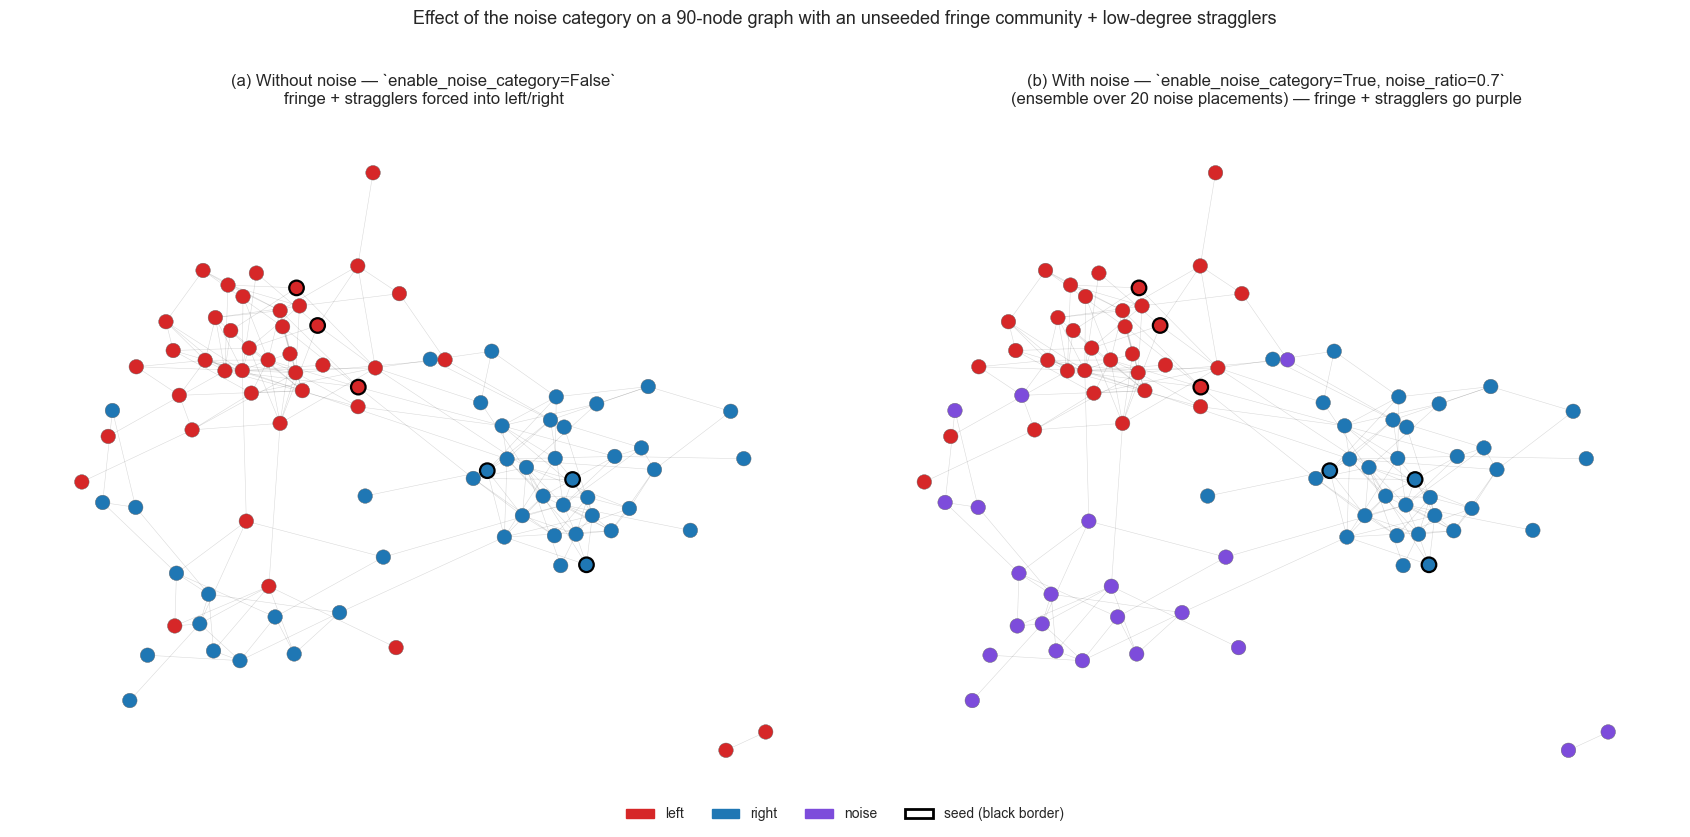

In [8]:
# Build messy graph example 
G_messy = nx.Graph()
for i in range(messy_graph.numberOfNodes()):
    G_messy.add_node(messy_mapper.get_original(i))
for u, v in messy_graph.iterEdges():
    G_messy.add_edge(messy_mapper.get_original(u), messy_mapper.get_original(v))
messy_pos = nx.spring_layout(G_messy, seed=42, k=0.35, iterations=80)

messy_seed_set = set(messy_seeds.keys())
palette = {"left": "#d62728", "right": "#1f77b4", "noise": "#7d4cdb"}
node_ids = [messy_mapper.get_original(i)
            for i in range(messy_graph.numberOfNodes())]

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
for ax, result, title in [
    (axes[0], result_no_noise,
     "(a) Without noise — `enable_noise_category=False`\n"
     "fringe + stragglers forced into left/right"),
    (axes[1], result_with_noise,
     "(b) With noise — `enable_noise_category=True, noise_ratio=0.7`\n"
     "(ensemble over 20 noise placements) — fringe + stragglers go purple"),
]:
    node_to_label = dict(zip(result["node_id"].to_list(),
                             result["dominant_label"].to_list()))
    colors, edgecolors, linewidths = [], [], []
    for nid in node_ids:
        dom = node_to_label.get(nid, None)
        colors.append(palette.get(dom, "#dddddd"))
        edgecolors.append("black" if nid in messy_seed_set else "#666")
        linewidths.append(1.6 if nid in messy_seed_set else 0.3)

    nx.draw_networkx_edges(G_messy, messy_pos, ax=ax, alpha=0.15, width=0.4)
    nx.draw_networkx_nodes(G_messy, messy_pos, ax=ax,
                           node_color=colors, node_size=110,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend = [
    mpatches.Patch(color=palette["left"], label="left"),
    mpatches.Patch(color=palette["right"], label="right"),
    mpatches.Patch(color=palette["noise"], label="noise"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2,
                   label="seed (black border)"),
]
fig.legend(handles=legend, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle("Effect of the noise category on a 90-node graph with an "
             "unseeded fringe community + low-degree stragglers",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Watching noise propagate over iterations.** The side-by-side above shows the converged result. Here are the per-iteration snapshots of a *single* with-noise run on the same graph: at $t = 0$ the only coloured nodes are the 6 user seeds (red / blue) and the 4 randomly-placed noise seeds (purple). By $t = 2$ noise mass has spread from its anchors and competes with left/right in their respective neighborhoods; by convergence noise has dominated the fringe community and most stragglers, while left/right hold their own communities.

A single run shows *where* noise specifically landed — the side-by-side above used `ensemble_label_propagation(n_epochs=20)` to *average* over 20 different noise placements, which is what you'd do in practice for stable estimates.


In [9]:
# Sample noise seeds
# (same helper, same random_seed → byte-identical placement).
noise_seed_dict = _generate_noise_seeds(
    messy_graph, messy_mapper, messy_seeds,
    noise_ratio=0.7, random_seed=42,
)
messy_seeds_aug = {**messy_seeds, **noise_seed_dict}
messy_labels_aug = messy_labels + ["noise"]

#print(f"Sampled {len(noise_seed_dict)} noise seeds at "
      #f"noise_ratio=0.7 × {len(messy_seeds)} user seeds:")
#print(f"  {sorted(noise_seed_dict.keys())}")

messy_snapshots = propagate_with_snapshots(
    messy_graph, messy_mapper,
    messy_seeds_aug, messy_labels_aug,
    alpha=0.85, max_iterations=60,
)
#print(f"\nSingle-run propagation converged after "
      #f"{len(messy_snapshots) - 1} iterations")


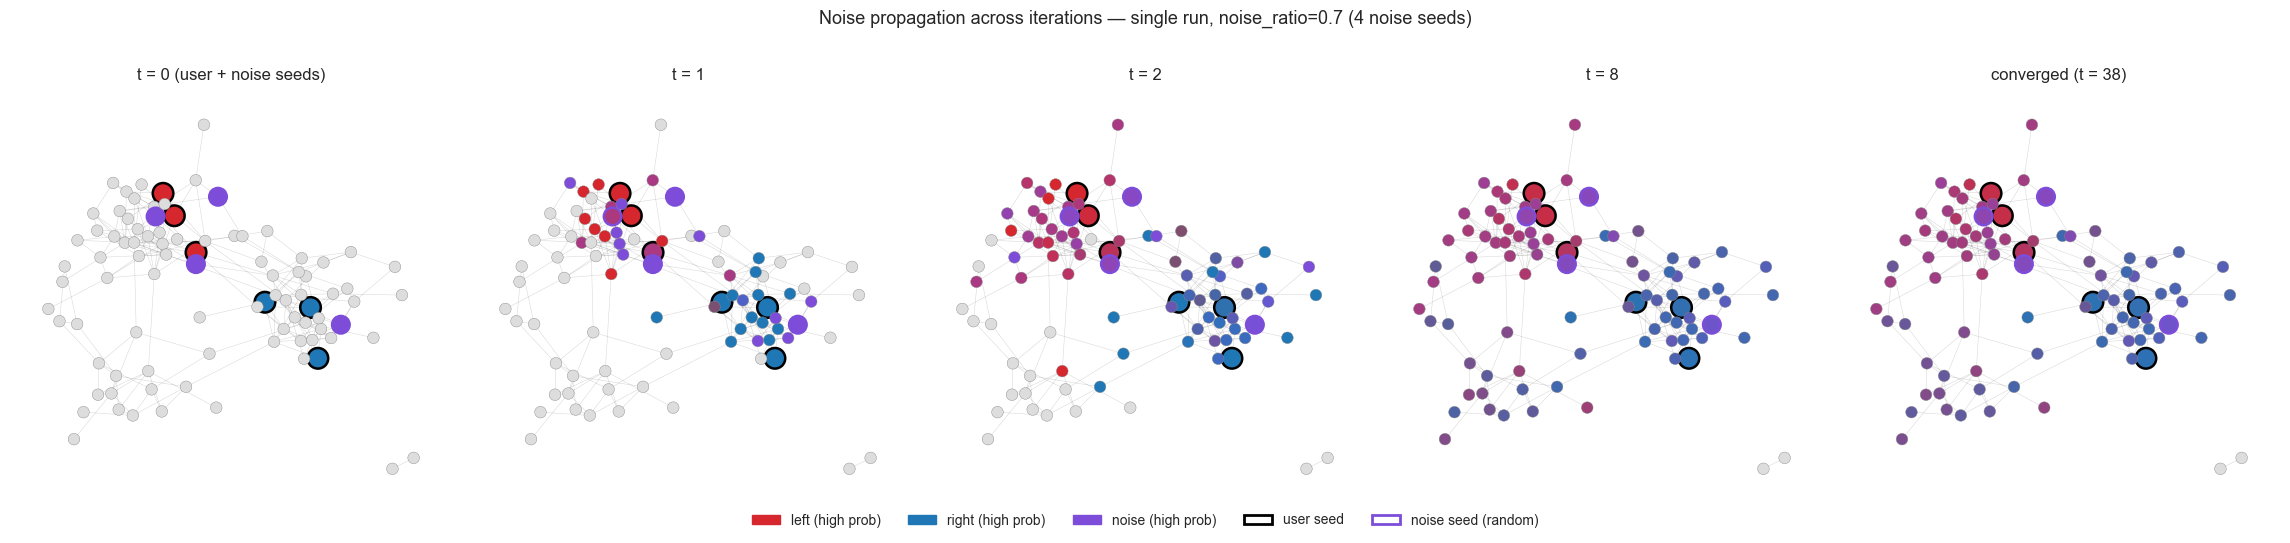

In [10]:
# Simulate noise propagation
converged_idx = len(messy_snapshots) - 1
panel_indices = [0, 1, 2, 8, converged_idx]
panel_titles = ["t = 0 (user + noise seeds)", "t = 1", "t = 2", "t = 8",
                f"converged (t = {converged_idx})"]

user_seed_set = set(messy_seeds.keys())
noise_seed_set = set(noise_seed_dict.keys())

color_left  = np.array([0.84, 0.15, 0.18])  # red
color_right = np.array([0.12, 0.47, 0.71])  # blue
color_noise = np.array([0.49, 0.30, 0.85])  # purple

node_ids_messy = [messy_mapper.get_original(i)
                  for i in range(messy_graph.numberOfNodes())]

fig, axes = plt.subplots(1, 5, figsize=(23, 5.0))
for ax, t_idx, title in zip(axes, panel_indices, panel_titles):
    F = messy_snapshots[t_idx]
    row_sums = F.sum(axis=1, keepdims=True)
    F_norm = np.where(row_sums > 0, F / np.maximum(row_sums, 1e-12), 0.0)

    colors, sizes, edgecolors, linewidths = [], [], [], []
    for i, nid in enumerate(node_ids_messy):
        if F_norm[i].sum() == 0:
            colors.append("#dddddd")
        else:
            blended = (F_norm[i, 0] * color_left
                       + F_norm[i, 1] * color_right
                       + F_norm[i, 2] * color_noise)
            colors.append(tuple(np.clip(blended, 0, 1)))

        if nid in user_seed_set:
            sizes.append(220)
            edgecolors.append("black")
            linewidths.append(1.8)
        elif nid in noise_seed_set:
            sizes.append(160)
            edgecolors.append(tuple(color_noise))
            linewidths.append(1.8)
        else:
            sizes.append(70)
            edgecolors.append("#888")
            linewidths.append(0.3)

    nx.draw_networkx_edges(G_messy, messy_pos, ax=ax, alpha=0.15, width=0.4)
    nx.draw_networkx_nodes(G_messy, messy_pos, ax=ax,
                           node_color=colors, node_size=sizes,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend = [
    mpatches.Patch(color=tuple(color_left),  label="left (high prob)"),
    mpatches.Patch(color=tuple(color_right), label="right (high prob)"),
    mpatches.Patch(color=tuple(color_noise), label="noise (high prob)"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2,
                   label="user seed"),
    mpatches.Patch(facecolor="white", edgecolor=tuple(color_noise),
                   linewidth=2, label="noise seed (random)"),
]
fig.legend(handles=legend, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.04), frameon=False)
fig.suptitle("Noise propagation across iterations — "
             f"single run, noise_ratio=0.7 ({len(noise_seed_dict)} noise seeds)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Pipeline + train/test on Facebook data

The headline workflow: 1 year of public Danish Facebook URL-sharing data → backboned page-to-page graph → GLP from a small set of known-affiliation pages → held-out train/test on those same seeds.

Four pipeline stages (Polars + NetworkIt + sparse SciPy throughout):

1. `build_edgelist_from_frame` — encode page/URL strings as UInt32 codes.
2. `apply_backbone(bipartite_svn)` — keep statistically significant page–URL ties.
3. `temporal_bipartite_to_unipartite` — collapse URLs into directed page→page edges (later sharer → earlier sharer).
4. `apply_backbone(noise_corrected)` — backbone the projected graph.

Per-stage timings print inline (`verbose=True`).


In [11]:
# Set workspace
DATA_DIR = Path("../demo_data")
OUTPUT_DIR = Path("output"); OUTPUT_DIR.mkdir(exist_ok=True)

# ── Required files (placeholders — supply your own) ──────────────────────────
# 1. Raw FB shares — columns: page_id (str), url (str), timestamp (date/datetime).
#    Optional: n_shares (int) — used as edge weight if present.
FB_SHARES_PATH = DATA_DIR / "echo_pol_3steps_fb.csv"

# 2. Politician seeds (left/right) — columns: node_id (=page_id), label.
#    In-domain seed set for Section 4a, and cross-domain test set in Section 5.
POLITICIANS_PATH = DATA_DIR / "pol_actors_w_party.csv"
dk_party_labels = pl.read_csv(POLITICIANS_PATH).filter(~pl.col("party").is_in(["Frie Grønne","Siumut"])).drop_nulls().select(["actor_platform","party"]).rename({"actor_platform":"node_id","party":"label"})
dk_bi_labels = pl.read_csv(POLITICIANS_PATH).drop_nulls().select(["actor_platform","bi_"]).rename({"actor_platform":"node_id","bi_":"label"})

# 4. Partisan news URL/domain seeds (Section 5 content_seeds) — columns: url, label.
PARTISAN_NEWS_PATH = DATA_DIR / "danish_altmed_web_list_w_pol.csv"
dk_alt = pl.read_csv(PARTISAN_NEWS_PATH)
dk_alt = dk_alt.with_columns(pl.col("node_id").str.replace("https://", ""))
dk_alt = dk_alt.with_columns(pl.col("label").str.to_lowercase().alias("label")).filter(pl.col("label").is_in(["left","right"]))
dk_alt = dk_alt.with_columns((pl.col("node_id").str.split("/").list.get(0)).alias("domain"))
dk_alt = dk_alt.with_columns((pl.col("domain").str.split("?").list.get(0)).alias("domain"))


In [12]:
# Load real world data
shares = pl.read_csv(FB_SHARES_PATH).select(["o","e","dt","w"]).with_columns((pl.col("dt").str.slice(0,length=19).str.to_datetime("%Y-%m-%dT%H:%M:%S")).alias("dt")).sort(["o","dt"],descending=True).filter(pl.col("e")!="None_Facebook Group")
stat_users = shares.with_columns((pl.col("o").str.split("/").list.get(0)).alias("domain")).with_columns((pl.col("domain").str.split("?").list.get(0)).alias("domain")).filter(pl.col("domain").is_in(dk_alt["domain"])).select("o","e","domain").join(dk_alt,on="domain",how="left").unique(["o"])#.select("o","label").rename({"o":"node_id"})
stat_users = stat_users.group_by(["e","domain"]).agg(pl.count(),pl.first("label"))
stat_users_labels = stat_users.select(["domain","label"]).unique(["domain","label"]).rename({"domain":"node_id"})
stat_users = stat_users.select(["domain","e","count"]).rename({"e":"source_id","domain":"target_id","count":"weight"})
print(f"Loaded {shares.height:,} share events")
#print(f"Columns: {shares.columns}")
#print(f"Date range: {shares['timestamp'].min()}  →  {shares['timestamp'].max()}")
print(f"Unique pages: {shares['e'].n_unique():,}")
print(f"Unique URLs:  {shares['o'].n_unique():,}")
shares.head(5)


/var/folders/1w/9385xj5d4gsdn_tbttb50cjh0000gp/T/ipykernel_45555/986608007.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  stat_users = shares.with_columns((pl.col("o").str.split("/").list.get(0)).alias("domain")).with_columns((pl.col("domain").str.split("?").list.get(0)).alias("domain")).filter(pl.col("domain").is_in(dk_alt["domain"])).select("o","e","domain").join(dk_alt,on="domain",how="left").unique(["o"])#.select("o","label").rename({"o":"node_id"})
/var/folders/1w/9385xj5d4gsdn_tbttb50cjh0000gp/T/ipykernel_45555/986608007.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  stat_users = stat_users.group_by(["e","domain"]).agg(pl.count(),pl.first("label"))


Loaded 21,035,585 share events
Unique pages: 28,225
Unique URLs:  16,830,862


o,e,dt,w
str,str,datetime[μs],i64
"""zzz.bedrenaetter.dk/outlet](zz…","""193551540805898_Facebook Group""",2022-12-01 09:36:14,1
"""zzwave.com/plaboard/posts/3968…","""504143656428853_Facebook Group""",2022-02-25 01:54:16,1
"""zzwave.com/plaboard/posts/3968…","""VolusiaCountyRepublicanParty_F…",2022-02-24 19:23:13,1
"""zzs-blg.blogspot.com/2022/09/c…","""121827024509492_Facebook Group""",2022-10-16 21:21:48,1
"""zzoomm.teamtailor.com/jobs/209…","""152966601945731_Facebook Group""",2022-10-17 14:36:28,1


In [13]:
# Network backboning
seeds_df = dk_bi_labels
result = run_canonical_pipeline(
    source=shares,
    source_col="e",
    target_col="o",
    timestamp_col="dt",
    weight_col="w",
    intermediate_col="o",
    projected_col="e",
    min_source_degree=3,
    min_target_degree=None,
    auto_weight=False,
    bipartite_overlap="drop",
    bipartite_alpha=0.005,
    bipartite_correction="fdr_bh",
    bipartite_target_fraction=0.9,
    add_edge_weights=True,
    remove_self_loops=True,
    presort_temporal=True,
    projection_threshold=1.0,
    projection_target_fraction=0.3,
    memory_mode="balanced",
    checkpoint_dir=None,
    keep_intermediates=False,
    verbose=False,
    protected_nodes=seeds_df["node_id"].to_list(),
    bipartite_min_node_retention=0.1,
)


/Users/jakobbk/Documents/postdoc/codespace/guidedLabelPropagation/guidedLP/src/guidedLP/network/construction.py:1075: UserWarning: Degree filter dropped 4420 of 21035585 edges; sources: kept 25344/28225 (min_source_degree=3)
  warnings.warn(


In [14]:
# Build final graph
# Bare definitions required by downstream cells (graph/seeds derivations).
graph, mapper = edgelist_to_graph(result.edgelist, result.id_mapper)
seed_dict = dict(zip(seeds_df["node_id"].to_list(), seeds_df["label"].to_list()))
labels = sorted(seeds_df["label"].unique().to_list())

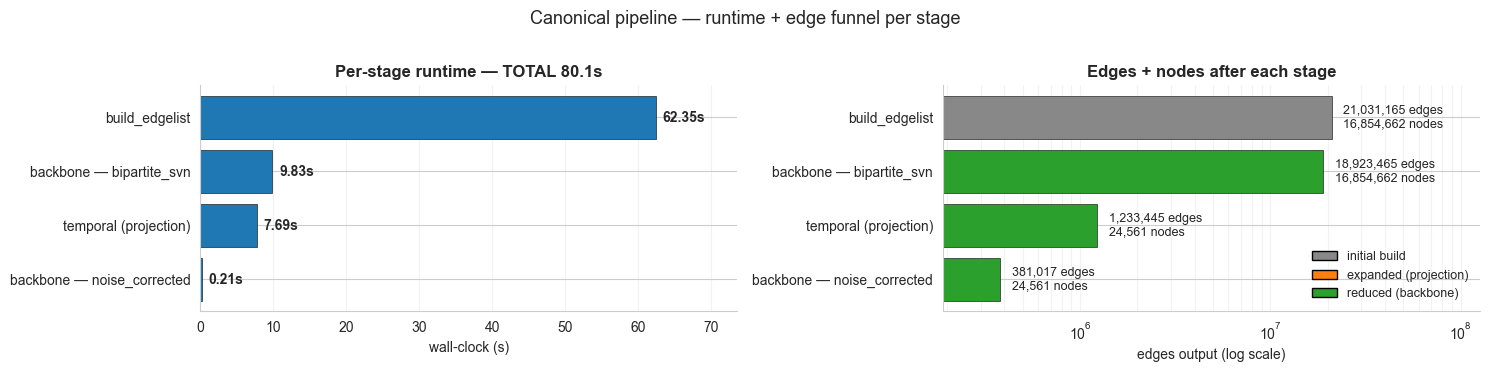

In [15]:
# Visual receipt for the "fast" claim — per-stage wall-clock + edge funnel.
# Shortened names so the y-axis stays readable.
_shorten = lambda n: (n.replace("apply_backbone(", "backbone — ").replace(")", "")
                       .replace("_from_frame", "")
                       .replace("_bipartite_to_unipartite", " (projection)"))
stage_names = [_shorten(s.name) for s in result.stage_stats]
durations    = [s.duration_s for s in result.stage_stats]
output_edges = [s.output_edges or 0 for s in result.stage_stats]
output_nodes = [s.output_nodes or 0 for s in result.stage_stats]
total_dur    = sum(durations)
y_pos        = np.arange(len(stage_names))

fig, (ax_dur, ax_e) = plt.subplots(
    1, 2, figsize=(15, max(3.5, 0.9 * len(stage_names))),
)

# --- Left panel: per-stage runtime ---
ax_dur.barh(y_pos, durations, color="#1f77b4",
            edgecolor="black", linewidth=0.4)
for y, d in zip(y_pos, durations):
    ax_dur.text(d + max(durations) * 0.015, y, f"{d:.2f}s",
                va="center", fontsize=10, fontweight="bold")
ax_dur.invert_yaxis()
ax_dur.set_yticks(y_pos)
ax_dur.set_yticklabels(stage_names, fontsize=10)
ax_dur.set_xlabel("wall-clock (s)")
ax_dur.set_xlim(0, max(durations) * 1.18)
ax_dur.set_title(f"Per-stage runtime — TOTAL {total_dur:.1f}s",
                 fontsize=12, fontweight="bold")
ax_dur.spines["top"].set_visible(False)
ax_dur.spines["right"].set_visible(False)
ax_dur.grid(axis="x", alpha=0.25)

# --- Right panel: output edges (log scale, colored by direction of change) ---
prev = None; colors = []
for oe in output_edges:
    if prev is None:
        colors.append("#888888")          # initial build
    elif oe > prev:
        colors.append("#ff7f0e")          # expanded (projection)
    else:
        colors.append("#2ca02c")          # reduced (backbone)
    prev = oe

ax_e.barh(y_pos, output_edges, color=colors,
          edgecolor="black", linewidth=0.4)
for y, oe, on in zip(y_pos, output_edges, output_nodes):
    if oe:
        ax_e.text(oe * 1.15, y, f"{oe:,} edges\n{on:,} nodes",
                  va="center", fontsize=9)
ax_e.invert_yaxis()
ax_e.set_yticks(y_pos)
ax_e.set_yticklabels(stage_names, fontsize=10)
ax_e.set_xscale("log")
ax_e.set_xlim(min(o for o in output_edges if o) / 2,
              max(output_edges) * 6)
ax_e.set_xlabel("edges output (log scale)")
ax_e.set_title("Edges + nodes after each stage",
               fontsize=12, fontweight="bold")
ax_e.spines["top"].set_visible(False)
ax_e.spines["right"].set_visible(False)
ax_e.grid(axis="x", alpha=0.25, which="both")

from matplotlib.patches import Patch
ax_e.legend(handles=[
    Patch(facecolor="#888888", edgecolor="black", label="initial build"),
    Patch(facecolor="#ff7f0e", edgecolor="black", label="expanded (projection)"),
    Patch(facecolor="#2ca02c", edgecolor="black", label="reduced (backbone)"),
], loc="lower right", fontsize=9, frameon=False)

fig.suptitle("Canonical pipeline — runtime + edge funnel per stage",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4a. Held-out train/test

We hold out 20% of the labelled seeds (stratified so label proportions are preserved), train GLP on the rest, and score predictions on the held-out portion. `directional=True` runs both passes; we score the **out-degree** pass (each page labelled by what it cites). `enable_noise_category=True` adds a `noise` column populated by `noise_ratio × n_user_seeds` random non-seed nodes.

The two error counts in the result dict are the conceptual contribution here:

- **`noise_errors`** — held-out seeds the model classified as `noise`. The model said *"I'm not sure"* and was technically wrong. These are recoverable: a smaller `noise_ratio` or a richer seed set would likely catch them.
- **`hard_errors`** — held-out seeds the model assigned to a *wrong real label* with confidence. These are the real failures.


In [16]:
# Validation left/right politicians
val_results = train_test_split_validation(
    graph=graph,
    id_mapper=mapper,
    seed_labels=seeds_df,
    labels=list(set(seeds_df["label"].to_list())),
    test_size=0.5,
    stratify=True,
    random_seed=43,
    # GLP kwargs passed through:
    alpha=0.85,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    noise_ratio=.75,
    propagator=ensemble_label_propagation,
    distance_prior=False,
    max_iterations=1500,
    n_epochs=30,
    weight_transform=winsorize_transform(cap=10),
)


[ensemble_label_propagation] 2.00s | nodes=24,561 edges=381,017 | seeds=78 labels=2 alpha=0.85 epochs=30 | output=directional (tuple)


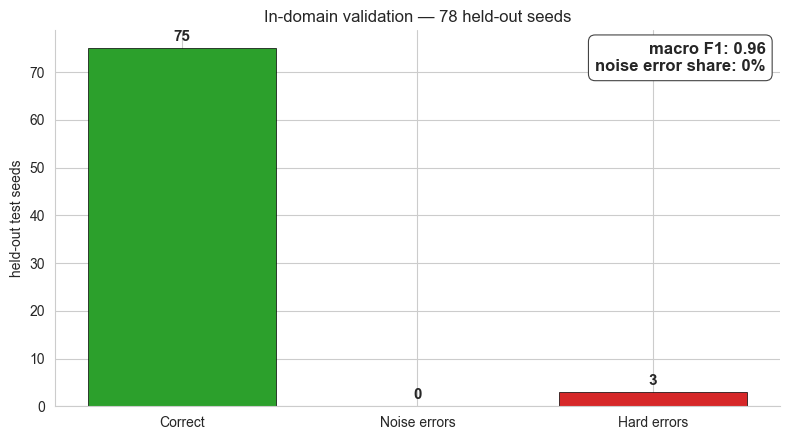

In [17]:
# Number of errors — in-domain (left/right) train/test breakdown.
counts = {
    "Correct":      int(round(val_results["accuracy"] * val_results["test_size"])),
    "Noise errors": int(val_results["noise_errors"]),
    "Hard errors":  int(val_results["hard_errors"]),
}
macro_f1    = val_results["macro_f1"]
noise_share = val_results["noise_error_share"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.keys(), counts.values(),
              color=["#2ca02c", "#bbbbbb", "#d62728"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + max(counts.values()) * 0.02,
            f"{val}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("held-out test seeds")

# Headline metrics — boxed annotation, prominent in the upper-right.
ax.text(0.98, 0.97,
        f"macro F1: {macro_f1:.2f}\nnoise error share: {noise_share:.0%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#444", linewidth=0.8))

ax.set_title(f"In-domain validation — {val_results['test_size']} held-out seeds")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 4b. Multi-class — predicting individual party affiliation

Same train/test setup, same graph, same seeds — but now each politician's label is their *party* (10 classes) rather than left/right (2 classes). The class distribution is **heavily unbalanced**: the largest party has 40+ members, the smallest just 4. GLP handles this without per-class re-weighting because the $(1{-}\alpha)Y$ anchor keeps every seed's per-label probability at 1.0 throughout propagation, regardless of how many siblings the seed has in its class.

The visual below shows:
- **Left panel** — per-class held-out test breakdown (correct vs misclassified) with each bar annotated by the party's total seed count `n=...`, so the imbalance is visible.
- **Right panel** — side-by-side comparison of left/right (2 classes) vs party (10 classes) on macro F1 and total errors. Despite 5× more classes, both metrics stay competitive.

In [18]:
# Multi-class run — same kwargs as 4a, only the seed labels change.
party_seeds_df = dk_party_labels
party_val = train_test_split_validation(
    graph=graph,
    id_mapper=mapper,
    seed_labels=party_seeds_df,
    labels=list(set(party_seeds_df["label"].to_list())),
    test_size=0.4,
    stratify=True,
    random_seed=42,
    # GLP kwargs passed through:
    alpha=0.85,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    noise_ratio=0.7,
    propagator=ensemble_label_propagation,
    distance_prior=False,
    max_iterations=1500,
    n_epochs=30,
    weight_transform=winsorize_transform(cap=10),
)


[ensemble_label_propagation] 6.55s | nodes=24,561 edges=381,017 | seeds=92 labels=11 alpha=0.85 epochs=30 | output=directional (tuple)


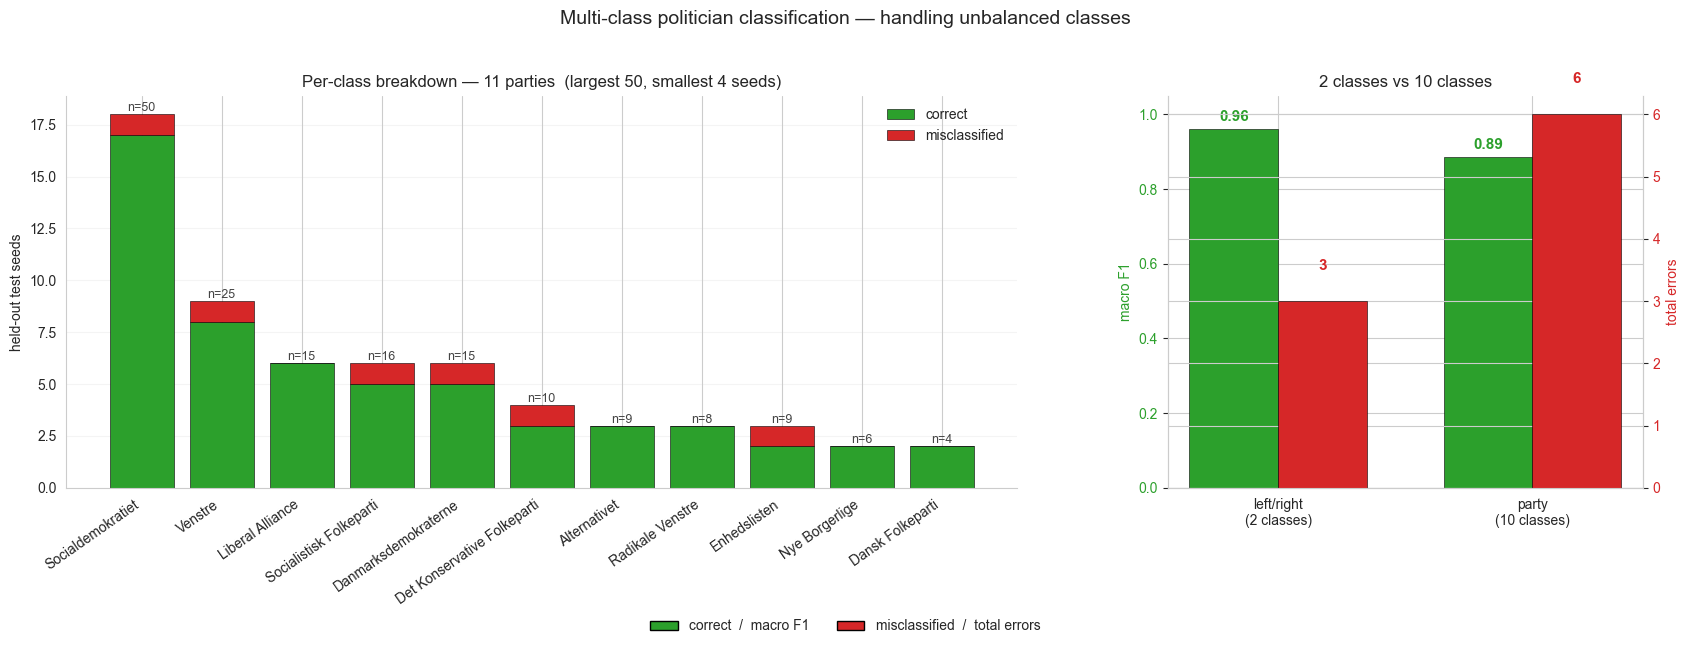

In [19]:
# Per-class accuracy from the held-out predictions.
party_seed_dict = dict(zip(party_seeds_df['node_id'].to_list(), party_seeds_df['label'].to_list()))
test_preds = party_val["test_predictions"].with_columns(
    true_label=pl.col("node_id").map_elements(
        lambda nid: party_seed_dict.get(nid), return_dtype=pl.Utf8),
).with_columns(
    correct=(pl.col("dominant_label") == pl.col("true_label")),
)
per_class = (
    test_preds.group_by("true_label")
    .agg(n_correct=pl.col("correct").sum(),
         n_test=pl.len())
    .with_columns(n_wrong=pl.col("n_test") - pl.col("n_correct"))
    .sort("n_test", descending=True)
)
# Total seeds per class (for the n=... annotations).
class_total = dict(zip(
    party_seeds_df["label"].value_counts().sort("count", descending=True)["label"].to_list(),
    party_seeds_df["label"].value_counts().sort("count", descending=True)["count"].to_list(),
))

# === Figure: per-class breakdown (left) + 2-class vs 10-class comparison (right) ===
fig = plt.figure(figsize=(17, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[2.0, 0.05, 1.0])
ax_main = fig.add_subplot(gs[0, 0])
ax_cmp  = fig.add_subplot(gs[0, 2])

# --- Left panel: per-class stacked bars
class_names = per_class["true_label"].to_list()
n_correct = per_class["n_correct"].to_list()
n_wrong = per_class["n_wrong"].to_list()
x_pos = np.arange(len(class_names))

ax_main.bar(x_pos, n_correct, color="#2ca02c", edgecolor="black",
            linewidth=0.4, label="correct")
ax_main.bar(x_pos, n_wrong, bottom=n_correct, color="#d62728", edgecolor="black",
            linewidth=0.4, label="misclassified")

for i, name in enumerate(class_names):
    total = class_total.get(name, 0)
    height = n_correct[i] + n_wrong[i]
    ax_main.text(i, height + 0.15, f"n={total}", ha="center", fontsize=9, color="#444")

ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(class_names, rotation=35, ha="right")
ax_main.set_ylabel("held-out test seeds")
sizes = [class_total.get(n, 0) for n in class_names]
ax_main.set_title(f"Per-class breakdown — {len(class_names)} parties  "
                  f"(largest {max(sizes)}, smallest {min(sizes)} seeds)")
ax_main.legend(loc="upper right", frameon=False)
ax_main.spines["top"].set_visible(False)
ax_main.spines["right"].set_visible(False)
ax_main.grid(axis="y", alpha=0.2)

# --- Right panel: 2-class vs 10-class comparison
metrics = ["left/right\n(2 classes)", "party\n(10 classes)"]
f1_vals = [val_results["macro_f1"], party_val["macro_f1"]]
err_vals = [val_results["total_errors"], party_val["total_errors"]]
x_pos_cmp = np.arange(len(metrics))
width = 0.35

bars_f1 = ax_cmp.bar(x_pos_cmp - width / 2, f1_vals, width,
                     color="#2ca02c", edgecolor="black", linewidth=0.4)
ax_cmp.set_ylim(0, 1.05)
ax_cmp.set_ylabel("macro F1", color="#2ca02c")
ax_cmp.tick_params(axis="y", labelcolor="#2ca02c")
for bar, v in zip(bars_f1, f1_vals):
    ax_cmp.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}",
                ha="center", fontsize=11, fontweight="bold", color="#2ca02c")

ax2_cmp = ax_cmp.twinx()
bars_err = ax2_cmp.bar(x_pos_cmp + width / 2, err_vals, width,
                       color="#d62728", edgecolor="black", linewidth=0.4)
ax2_cmp.set_ylabel("total errors", color="#d62728")
ax2_cmp.tick_params(axis="y", labelcolor="#d62728")
for bar, v in zip(bars_err, err_vals):
    ax2_cmp.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{int(v)}",
                 ha="center", fontsize=11, fontweight="bold", color="#d62728")

ax_cmp.set_xticks(x_pos_cmp)
ax_cmp.set_xticklabels(metrics)
ax_cmp.set_title("2 classes vs 10 classes")
ax_cmp.spines["top"].set_visible(False)
ax2_cmp.spines["top"].set_visible(False)

# Combined legend below the figure
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc="#2ca02c", ec="black"),
    plt.Rectangle((0, 0), 1, 1, fc="#d62728", ec="black"),
]
fig.legend(legend_handles, ["correct  /  macro F1", "misclassified  /  total errors"],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Multi-class politician classification — handling unbalanced classes",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4c. The `noise_ratio` knob, swept

Quick sweep over `noise_ratio` ∈ {0, 0.1, 0.3, 0.5, 1.0} to make the regularization story concrete: as you raise `noise_ratio`, the noise category absorbs more uncertain mass — `noise_errors` rises while `hard_errors` falls. The right operating point is wherever `macro_f1` peaks (and at that point, `noise_error_share` is a cleaner accounting of what the model still got wrong than raw error count).


In [20]:
grid = GLPGridSearch(
    graph=graph,
    id_mapper=mapper,
    seed_labels=seeds_df,
    labels=labels,
    # Sweep noise_ratio; everything else fixed.
    noise_ratio_grid=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    alpha_grid=[0.85],
    test_size_grid=[0.2],
    # Single GLP per cell (n_epochs_grid=[1]) keeps the sweep snappy on real
    # data — change to e.g. [10] to switch to noise-resampled ensembling.
    n_epochs_grid=[1],
    n_repeats=3,
    random_seed=42,
    stratify=True,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    verbose=False,
)
grid_df = grid.run()
summary = grid.summary(sort_by="noise_ratio", descending=False)


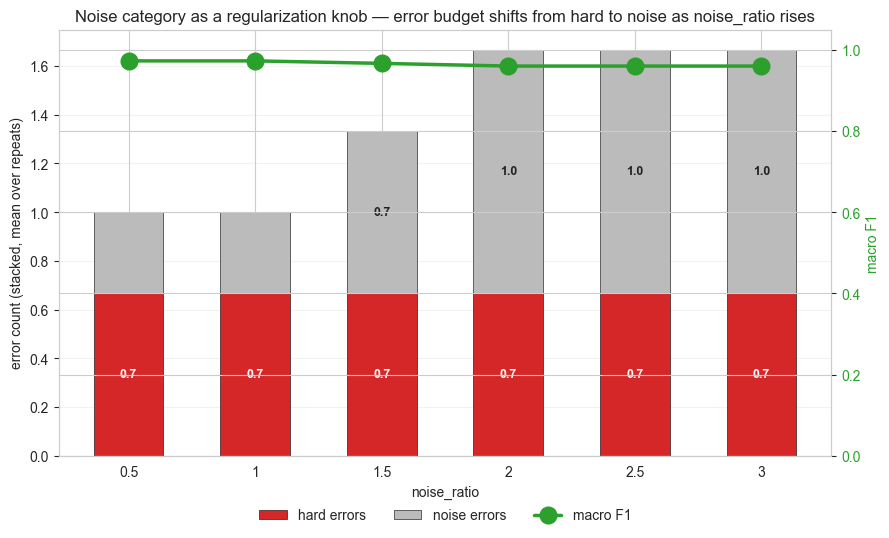

In [21]:
# Show noise
xs = summary["noise_ratio"].to_list()
hard = summary["hard_errors_mean"].to_list()
noise = summary["noise_errors_mean"].to_list()
f1 = summary["macro_f1_mean"].to_list()

# Categorical x positions so the uneven noise_ratio spacing doesn't squish
# the leftmost bars together.
x_pos = np.arange(len(xs))
x_labels = [f"{x:g}" for x in xs]

fig, ax1 = plt.subplots(figsize=(9, 5.2))

# Stacked bars: hard at bottom, noise on top. Total height = total errors.
ax1.bar(x_pos, hard, width=0.55, color="#d62728", edgecolor="black",
        linewidth=0.4, label="hard errors")
ax1.bar(x_pos, noise, width=0.55, bottom=hard, color="#bbbbbb",
        edgecolor="black", linewidth=0.4, label="noise errors")

# Annotate counts on each segment (skip tiny ones to avoid clutter).
for x, h, n in zip(x_pos, hard, noise):
    if h >= 0.5:
        ax1.text(x, h / 2, f"{h:.1f}", ha="center", va="center",
                 fontsize=9, color="white", fontweight="bold")
    if n >= 0.5:
        ax1.text(x, h + n / 2, f"{n:.1f}", ha="center", va="center",
                 fontsize=9, color="#222", fontweight="bold")

ax1.set_xlabel("noise_ratio")
ax1.set_ylabel("error count (stacked, mean over repeats)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.grid(True, axis="y", alpha=0.25)

# Macro F1 on the twin axis.
ax2 = ax1.twinx()
ax2.plot(x_pos, f1, "o-", color="#2ca02c", linewidth=2.5, markersize=12,
         label="macro F1")
ax2.set_ylabel("macro F1", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")
ax2.set_ylim(0, 1.05)

# Combined legend BELOW the plot — never overlaps the data.
lines, labs = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    lines += h; labs += l
fig.legend(lines, labs, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

ax1.set_title("Noise category as a regularization knob — "
              "error budget shifts from hard to noise as noise_ratio rises")
plt.tight_layout()
plt.show()

## 5. Cross-domain: partisan news → politicians

Same FB data, but the seeding scheme is *different from the test target*:

- **Seeds** = partisan news URLs / domains (content side of the bipartite). These are not pages — they are URLs / domains that pages share.
- **Test set** = the politician page set used in Section 4 (Facebook pages with known party affiliation).

The seeds and the test set never overlap (URLs ≠ pages), and the structural distance between content-side seeds and page-side test nodes makes this a genuinely cross-domain test: *does the sharing-pattern signature learned from partisan news identify politicians by party affiliation?*

### Stat-user augmentation

The seeds live on the URL partition; we want labels on pages. Two options:

1. **Run GLP on the raw bipartite** with URL seeds → keep only page rows. Simple, but the random walk's period-2 behavior means user-to-user distance takes two hops per iteration.
2. **Stat-user augmentation (used here).** For each labelled URL $c$, create a synthetic anchor node `__stat__c` connected to every page that shared $c$. The anchors sit in the page partition of the projected graph, so GLP runs on a clean page-page space — and the $(1{-}\alpha)Y$ term keeps the anchors fixed throughout propagation.

`run_canonical_pipeline` accepts the stat-edges as `content_seeds` and attaches them between projection and the projection-side backbone (Stage 3.5). `protected_nodes` keeps the anchors past the backbone.

In [22]:
cross_result = run_canonical_pipeline(
    source=shares,
    source_col="e",
    target_col="o",
    timestamp_col="dt",
    weight_col="w",
    intermediate_col="o",
    projected_col="e",
    min_source_degree=3,
    min_target_degree=None,
    auto_weight=False,
    bipartite_overlap="drop",
    bipartite_alpha=0.005,
    bipartite_correction="fdr_bh",
    bipartite_target_fraction=0.9,
    add_edge_weights=True,
    remove_self_loops=True,
    presort_temporal=True,
    projection_threshold=1.0,
    projection_target_fraction=0.3,
    memory_mode="balanced",
    checkpoint_dir=None,
    keep_intermediates=False,
    verbose=False,
    protected_nodes=seeds_df["node_id"].to_list(),
    bipartite_min_node_retention=0.1,
    content_seeds=stat_users
)
cross_graph, cross_mapper = edgelist_to_graph(
    cross_result.edgelist, cross_result.id_mapper,
)

/Users/jakobbk/Documents/postdoc/codespace/guidedLabelPropagation/guidedLP/src/guidedLP/network/construction.py:1075: UserWarning: Degree filter dropped 4420 of 21035585 edges; sources: kept 25344/28225 (min_source_degree=3)
  warnings.warn(


In [23]:
#cross_labels = sorted(set(stat_seeds.values()))
cross_val = train_test_split_validation(
    graph=cross_graph,
    id_mapper=cross_mapper,
    seed_labels=stat_users_labels,
    labels=list(set(seeds_df["label"].to_list())),
    test_size=0.3,
    stratify=True,
    random_seed=42,
    # GLP kwargs passed through:
    alpha=0.95,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    noise_ratio=.5,
    propagator=ensemble_label_propagation,
    distance_prior=False,
    max_iterations=1500,
    n_epochs=40,
    weight_transform=winsorize_transform(cap=10),
    test_seeds=seeds_df
)


[ensemble_label_propagation] 2.37s | nodes=24,585 edges=381,438 | seeds=12 labels=2 alpha=0.95 epochs=40 | output=directional (tuple)


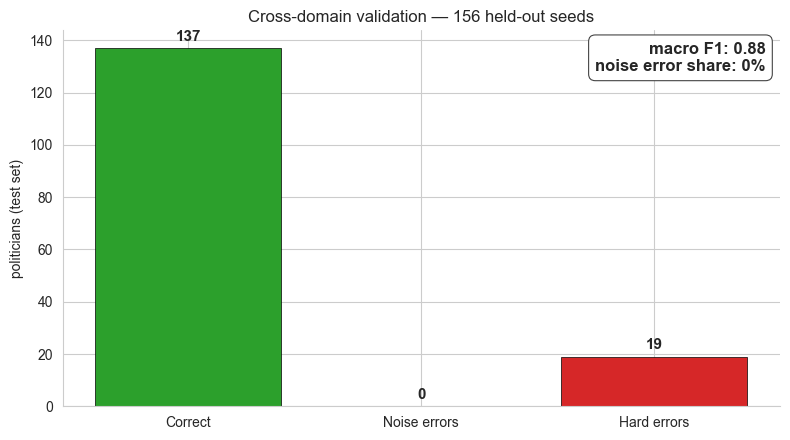

In [24]:
# Number of errors — cross-domain (partisan news → politicians).
counts = {
    "Correct":      int(round(cross_val["accuracy"] * cross_val["test_size"])),
    "Noise errors": int(cross_val["noise_errors"]),
    "Hard errors":  int(cross_val["hard_errors"]),
}
macro_f1    = cross_val["macro_f1"]
noise_share = cross_val["noise_error_share"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.keys(), counts.values(),
              color=["#2ca02c", "#bbbbbb", "#d62728"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + max(counts.values()) * 0.02,
            f"{val}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("politicians (test set)")

# Headline metrics — boxed annotation, prominent in the upper-right.
ax.text(0.98, 0.97,
        f"macro F1: {macro_f1:.2f}\nnoise error share: {noise_share:.0%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#444", linewidth=0.8))

ax.set_title(f"Cross-domain validation — {cross_val['test_size']} held-out seeds")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Visualization + Gephi export

To compare GLP against unsupervised community detection on the *same* graph:

1. Run **Louvain** consensus communities on the full backboned graph.
2. Reduce to a manageable subgraph for plotting via `filter_by_seed_proximity(method="ppr", top_n=400)` — keep the personalized-PageRank neighborhood of the seeds.
3. Render three matplotlib panels on the same layout: (a) Louvain coloring, (b) GLP dominant label, (c) GLP noise score.

Then export the **same** reduced subgraph as GEXF with per-node attributes (labels, probabilities, noise, is_seed, confidence) attached — ready to open in Gephi.


In [25]:
# Full-graph GLP — same setup as Section 4 (in-domain seeds).
full_out, full_in = guided_label_propagation(
    graph=cross_graph,
    id_mapper=cross_mapper,
    seed_labels=stat_users_labels,
    labels=list(set(seeds_df["label"].to_list())),
    alpha=0.85,
    directional=True,
    enable_noise_category=True,
    noise_ratio=0.7,
)
print(f"GLP on {graph.numberOfNodes():,} nodes — out-pass dominant_label counts:")
display(full_out["dominant_label"].value_counts())

# Full-graph Louvain (consensus over 5 runs).
# NetworkIt's PLM requires undirected; our `graph` is the directed temporal
# projection, so convert first. toUndirected preserves internal node IDs so
# `mapper` still works.
g_louvain = nk.graphtools.toUndirected(graph) if graph.isDirected() else graph
communities = detect_communities(
    graph=g_louvain, id_mapper=mapper,
    algorithm="louvain", iterations=5, random_seed=42, n_jobs=1,
)
n_cons = communities["community_consensus"].n_unique()
print(f"\nLouvain consensus: {n_cons} communities across {communities.height:,} nodes")


[guided_label_propagation] 0.46s | nodes=24,585 edges=381,438 | seeds=12 labels=2 alpha=0.8 | output=directional (tuple)
GLP on 24,561 nodes — out-pass dominant_label counts:


dominant_label,count
str,u32
"""left""",16672
"""right""",5422
"""noise""",2491



Louvain consensus: 77 communities across 24,561 nodes


In [26]:
# PPR neighborhood of the seeds, for a plottable subgraph.
sub_graph, sub_mapper = filter_by_seed_proximity(
    graph=graph, id_mapper=mapper,
    seeds=list(seed_dict.keys()),
    method="ppr",
    ppr_alpha=0.85,
    top_n=400,
    include_seeds=True,
)
print(f"Reduced subgraph: {sub_graph.numberOfNodes()} nodes, "
      f"{sub_graph.numberOfEdges()} edges")

# Layout once — reused across all three panels.
if HAS_NX:
    G_sub = nx.DiGraph() if sub_graph.isDirected() else nx.Graph()
    for i in range(sub_graph.numberOfNodes()):
        G_sub.add_node(sub_mapper.get_original(i))
    for u, v in sub_graph.iterEdges():
        G_sub.add_edge(sub_mapper.get_original(u), sub_mapper.get_original(v))
    sub_layout = nx.spring_layout(G_sub, seed=42, k=0.3, iterations=80)
    print("Layout ready.")
else:
    print("Install networkx for the visualization step.")


Reduced subgraph: 400 nodes, 5287 edges
Layout ready.


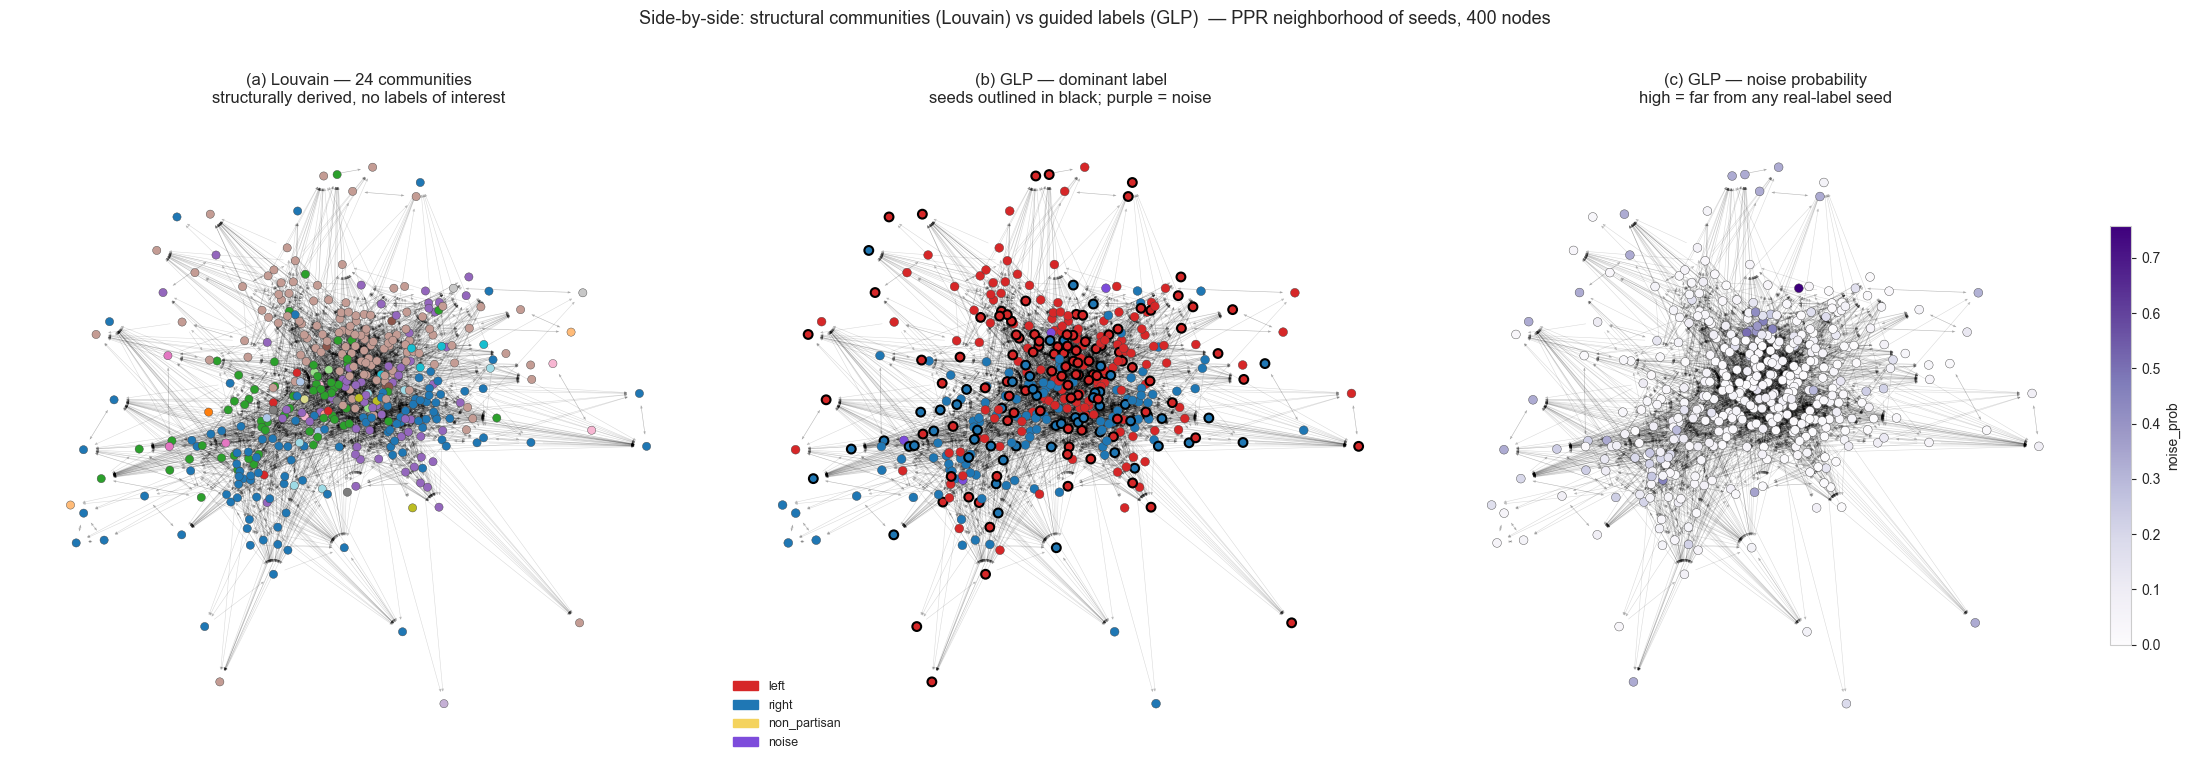

In [27]:
if HAS_NX:
    sub_node_ids = [sub_mapper.get_original(i)
                    for i in range(sub_graph.numberOfNodes())]
    sub_df = pl.DataFrame({"node_id": sub_node_ids})

    sub_lou = sub_df.join(
        communities.select(["node_id", "community_consensus"]),
        on="node_id", how="left",
    )
    sub_glp = sub_df.join(full_out, on="node_id", how="left")

    seed_set = set(seed_dict.keys())

    fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))

    # ── Panel A — Louvain ─────────────────────────────────────────────────
    ax = axes[0]
    lou_communities = sub_lou["community_consensus"].to_list()
    unique_lou = sorted({c for c in lou_communities if c is not None})
    lou_palette = plt.cm.tab20(np.linspace(0, 1, max(len(unique_lou), 1)))
    lou_colors = [
        "#dddddd" if c is None
        else lou_palette[unique_lou.index(c) % len(lou_palette)]
        for c in lou_communities
    ]
    nx.draw_networkx_edges(G_sub, sub_layout, ax=ax, alpha=0.15, width=0.4,
                           arrowsize=4 if sub_graph.isDirected() else 0)
    nx.draw_networkx_nodes(G_sub, sub_layout, ax=ax,
                           node_color=lou_colors, node_size=35,
                           edgecolors="#444", linewidths=0.3)
    ax.set_title(f"(a) Louvain — {len(unique_lou)} communities\n"
                 "structurally derived, no labels of interest", fontsize=12)
    ax.axis("off")

    # ── Panel B — GLP dominant label ──────────────────────────────────────
    ax = axes[1]
    glp_palette = {"left": "#d62728", "right": "#1f77b4",
                   "non_partisan": "#f4d35e", "noise": "#7d4cdb"}
    dom_labels = sub_glp["dominant_label"].to_list()
    glp_colors = [glp_palette.get(d, "#dddddd") for d in dom_labels]
    edgecolors = ["black" if nid in seed_set else "#444"
                  for nid in sub_node_ids]
    linewidths = [1.5 if nid in seed_set else 0.3 for nid in sub_node_ids]
    nx.draw_networkx_edges(G_sub, sub_layout, ax=ax, alpha=0.15, width=0.4,
                           arrowsize=4 if sub_graph.isDirected() else 0)
    nx.draw_networkx_nodes(G_sub, sub_layout, ax=ax,
                           node_color=glp_colors, node_size=40,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title("(b) GLP — dominant label\n"
                 "seeds outlined in black; purple = noise", fontsize=12)
    ax.axis("off")
    glp_legend = [mpatches.Patch(color=c, label=l)
                  for l, c in glp_palette.items()]
    ax.legend(handles=glp_legend, loc="lower left", fontsize=9, frameon=False)

    # ── Panel C — GLP noise score ─────────────────────────────────────────
    ax = axes[2]
    noise_col = "noise_prob" if "noise_prob" in sub_glp.columns else None
    if noise_col is None:
        ax.text(0.5, 0.5, "No noise column in result — re-run GLP with\n"
                          "enable_noise_category=True.",
                transform=ax.transAxes, ha="center", va="center")
        ax.axis("off")
    else:
        noise_probs = sub_glp[noise_col].fill_null(0.0).to_list()
        nx.draw_networkx_edges(G_sub, sub_layout, ax=ax, alpha=0.15,
                               width=0.4,
                               arrowsize=4 if sub_graph.isDirected() else 0)
        nodes = nx.draw_networkx_nodes(G_sub, sub_layout, ax=ax,
                                       node_color=noise_probs,
                                       cmap="Purples", node_size=40,
                                       edgecolors="#444", linewidths=0.3,
                                       vmin=0,
                                       vmax=max(0.05, max(noise_probs)))
        fig.colorbar(nodes, ax=ax, fraction=0.03, pad=0.02,
                     label="noise_prob")
        ax.set_title("(c) GLP — noise probability\n"
                     "high = far from any real-label seed", fontsize=12)
        ax.axis("off")

    fig.suptitle(
        "Side-by-side: structural communities (Louvain) vs guided labels (GLP)  "
        f"— PPR neighborhood of seeds, {sub_graph.numberOfNodes()} nodes",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()


### 6a. Gephi-ready export

`export_reduced_graph` runs a reduction (here `method="grouping"` = Louvain quotient graph) and writes a GEXF file with every node attribute attached. We pass the GLP result tuple as `glp_results=(out_df, in_df)`: per-label probabilities are averaged per supernode, plus `dominant_label`, `confidence`, `seed_fraction`. The file opens directly in Gephi 0.10+ with all attributes available in the Data Laboratory.


In [28]:
gexf_path = OUTPUT_DIR / "dk_fb_reduced.gexf"
# Influence-based reduction: apply_backbone (default noise_corrected) keeps
# the highest-leverage real nodes — preserves page identity, no aggregation.
# Works on directed graphs; no undirected conversion needed.
returned_path, reduced_g, reduced_mapper, node_attrs = export_reduced_graph(
    graph=graph,
    id_mapper=mapper,
    output_path=gexf_path,
    method="influence",
    glp_results=(full_out, full_in),
    glp_direction="out",
    target_nodes=2000,
    format="gexf",
    overwrite=True,
    return_reduced=True,
)
print(f"\nWrote {returned_path}")
print(f"Reduced graph: {reduced_g.numberOfNodes()} nodes, "
      f"{reduced_g.numberOfEdges()} edges")
print("\nFirst 5 nodes (preview of what's in the GEXF):")
display(node_attrs.head(5))


Wrote output/dk_fb_reduced.gexf
Reduced graph: 2000 nodes, 30453 edges

First 5 nodes (preview of what's in the GEXF):


node_id,left_prob,right_prob,noise_prob,dominant_label,confidence,is_seed
str,f64,f64,f64,str,f64,bool
"""100044360022428_Facebook Page""",0.330038,0.618074,0.051888,"""right""",0.618074,false
"""100063532930637_Facebook Page""",0.355993,0.050343,0.593664,"""noise""",0.593664,false
"""100063590635452_Facebook Page""",0.133084,0.750601,0.116315,"""right""",0.750601,false
"""100063643303178_Facebook Page""",0.969474,0.027312,0.003214,"""left""",0.969474,false
"""100063653915974_Facebook Page""",0.659744,0.251481,0.088774,"""left""",0.659744,false


## 7. Recap

| Unique claim | Demonstrated in |
|---|---|
| **Fast & memory-efficient at scale** (Polars + NetworkIt + streamlined backboning) | Section 4 — `run_canonical_pipeline` per-stage timings and the stage-stats table |
| **Noise as an interpretable regularizer** | Sections 4a–4b — noise vs hard error breakdown, `noise_ratio` sweep |
| **Reduced graph with full label/probability export** | Section 6a — `export_reduced_graph` → GEXF with `*_prob`, `dominant_label`, `confidence`, `is_seed` attributes |
| **Semi-supervised + cross-domain** | Section 4 (in-domain seeds → in-domain test) and Section 5 (newspaper-URL seeds → politician-page test via `make_stat_user_edges`) |

**Where to go from here:**

- `docs/architecture/glp.md` — directional-pass semantics, design rationale, stat-user augmentation theory
- `README.md` Examples 5–8 — additional pipeline shapes (`run_undirected_bipartite_pipeline`, `run_undirected_unipartite_pipeline`), `audience_composition_pass`, `cross_validate`
- `examples/example_propagation_animation.py` — full-resolution Plotly animation on real data
- `bipartite_glp_notes.md` — related literature on label-as-node / virtual-node constructions
